In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import seaborn as sns
import re, math
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from pathlib import Path
from brokenaxes import brokenaxes
import datetime, csv
from matplotlib.colors import LinearSegmentedColormap

ROOT = '/root/workspace/vllm-dynamic/scripts'
DATASET_PATH=f'{ROOT}/dataset/overhead'
PDF_PATH=f'{ROOT}/pdf'
line_styles = ['-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted', '-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '1', '2', '3', '4', '8', 'p', '*', 'h', 'H', '<', '>', 'd']
hatches = hatches = ['...', '--', '///', '\\\\\\', '+', 'x', 'o', 'O', '.', '*', '0', '1', '2', '3', '4', '5', '6', '7', '8']

In [14]:

def extract_optimization_time(log_file_path, csv_file_path):
    # 正则表达式模式
    time_pattern = r"allocate block time is (\d+\.\d+) ms"

    # 用于存储结果的列表
    records = []

    # 打开日志文件并读取内容
    with open(log_file_path, 'r') as log_file:
        log_content = log_file.read()

        # 查找所有匹配的Time和iteration
        time_matches = re.findall(time_pattern, log_content)
        
        # 计算每个匹配的Time
        for time in time_matches:
            # 将匹配的Time转换为整数并添加到记录中
            records.append(time)

    # 将记录转换为DataFrame
    df = pd.DataFrame(records, columns=['Time'])
    df.to_csv(csv_file_path, index=False)
    print(f"Extracted {len(records)} records to {csv_file_path}")       

In [34]:
dataset_name = 'sharegpt' 
num_prompt = 3024
# dataset_name = 'paper_assistant' 
# num_prompt = 184
model_name = 'meta-llama_Llama-2-70b-chat-hf'
num_gpu = 4
system_name = 'ellm'
input_log = f'{DATASET_PATH}/{system_name}/{dataset_name}/{model_name}_server_{num_prompt}_recompute_{num_gpu}gpu.log'
output_csv = input_log.replace('.log', '_find_index_time.csv')
# extract_optimization_time(input_log, output_csv)

In [69]:
def plot_overhead(csv_paths, data_names, metric):
    # 绘制优化时间CDF图
    fig = plt.figure(figsize=(3, 1.8), dpi=120)
    ax = fig.add_subplot(111)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for i, (csv_path, data_name) in enumerate(zip(csv_paths, data_names)):
        df = pd.read_csv(csv_path)
        df['Time'] = df['Time'].astype(float)
        df.sort_values('Time', inplace=True)
        print(f"数据集 {data_name} 的平均优化时间: {df['Time'].mean():.4f} ms, maximum优化时间: {df['Time'].max():.4f} ms, 最小优化时间: {df['Time'].min():.4f} ms")
        cdf = np.arange(len(df)) / float(len(df))
        ax.plot(df['Time'], cdf, label=data_name, color=plt.cm.tab20b(i/5), linestyle=line_styles[i+1])
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('CDF')
    ax.yaxis.set_major_locator(MultipleLocator(0.25))
    
    ax.grid(True, axis='y', linestyle='-.', linewidth=0.3, zorder=-10, alpha=0.5)
    ax.legend(loc='best', ncol=1, framealpha=1, frameon=False, columnspacing=0.3, labelspacing=0.5, handlelength=1, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.savefig(f'{PDF_PATH}/e2e_{metric}_overhead.pdf', bbox_inches='tight', dpi=120)

数据集 13B,ShareGPT 的平均优化时间: 4.5807 ms, maximum优化时间: 11.5819 ms, 最小优化时间: 0.9604 ms
数据集 13B,L-Eval 的平均优化时间: 2.9118 ms, maximum优化时间: 9.0334 ms, 最小优化时间: 1.1754 ms
数据集 70B,ShareGPT 的平均优化时间: 6.0374 ms, maximum优化时间: 20.4473 ms, 最小优化时间: 0.7961 ms
数据集 70B,L-Eval 的平均优化时间: 3.2535 ms, maximum优化时间: 15.3127 ms, 最小优化时间: 1.1475 ms


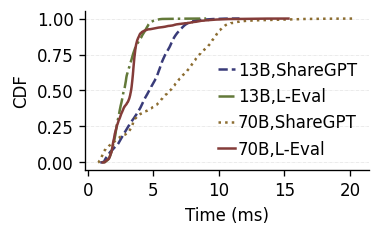

In [70]:
model_names = ['meta-llama_Llama-2-13b-chat-hf', 'meta-llama_Llama-2-70b-chat-hf']
num_gpus = [1, 4]
csv_paths = [
    f'{DATASET_PATH}/{system_name}/sharegpt/{model_names[0]}_server_3024_recompute_{num_gpus[0]}gpu_opt_time.csv',
    f'{DATASET_PATH}/{system_name}/paper_assistant/{model_names[0]}_server_184_recompute_{num_gpus[0]}gpu_opt_time.csv',
    f'{DATASET_PATH}/{system_name}/sharegpt/{model_names[1]}_server_3024_recompute_{num_gpus[1]}gpu_opt_time.csv',
    f'{DATASET_PATH}/{system_name}/paper_assistant/{model_names[1]}_server_184_recompute_{num_gpus[1]}gpu_opt_time.csv',
]
data_names = ['13B,ShareGPT', '13B,L-Eval', '70B,ShareGPT', '70B,L-Eval']
plot_overhead(csv_paths, data_names, 'request_level')

数据集 13B,ShareGPT 的平均优化时间: 0.0143 ms, maximum优化时间: 0.1046 ms, 最小优化时间: 0.0111 ms
数据集 13B,L-Eval 的平均优化时间: 0.0153 ms, maximum优化时间: 0.0699 ms, 最小优化时间: 0.0111 ms
数据集 70B,ShareGPT 的平均优化时间: 0.0132 ms, maximum优化时间: 0.1010 ms, 最小优化时间: 0.0104 ms
数据集 70B,L-Eval 的平均优化时间: 0.0143 ms, maximum优化时间: 0.0776 ms, 最小优化时间: 0.0079 ms


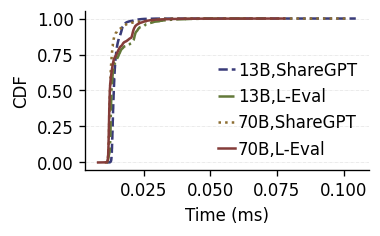

In [71]:
model_names = ['meta-llama_Llama-2-13b-chat-hf', 'meta-llama_Llama-2-70b-chat-hf']
num_gpus = [1, 4]
csv_paths = [
    f'{DATASET_PATH}/{system_name}/sharegpt/{model_names[0]}_server_3024_recompute_{num_gpus[0]}gpu_find_index_time.csv',
    f'{DATASET_PATH}/{system_name}/paper_assistant/{model_names[0]}_server_184_recompute_{num_gpus[0]}gpu_find_index_time.csv',
    f'{DATASET_PATH}/{system_name}/sharegpt/{model_names[1]}_server_3024_recompute_{num_gpus[1]}gpu_find_index_time.csv',
    f'{DATASET_PATH}/{system_name}/paper_assistant/{model_names[1]}_server_184_recompute_{num_gpus[1]}gpu_find_index_time.csv',
]
data_names = ['13B,ShareGPT', '13B,L-Eval', '70B,ShareGPT', '70B,L-Eval']
plot_overhead(csv_paths, data_names, 'find_index')

In [72]:
# 13B
h = 5120
V = 32000
r_range = (0, 1)

# 初始化可能的 l_1 和 l_2 值
l1_possible = [1, 2, 3]
l2_possible = [1, 2]
b_posibble = np.random.randint(1, 256)  # 假设b是1到256之间的整数
s_i_possible = np.random.randint(1, 4096, b_posibble)  # 假设s_i是1到10000之间的整数

import time

def calculate_V_K1(h, l1, l2, s_i_list, r):
    s_i_array = np.array(s_i_list, dtype=np.float64)
    term1 = 24 * h**2 * l2 * s_i_array * r
    term2 = 4 * h * l2 * s_i_array**2 * r**2
    term3 = 2 * h * V * s_i_array * r
    V_K1 = np.sum(term1 + term2 + term3)
    return V_K1

# 计算V_K2
def calculate_V_K2(h, l1, l2, s_i_list):
    s_i_array = np.array(s_i_list, dtype=np.float64)
    term1 = 24 * h**2 * (l1 + l2) * np.ones_like(s_i_array)
    term2 = 4 * h * (l1 + l2) * (s_i_array + 1)
    term3 = 2 * h * V * s_i_array
    V_K2 = np.sum(term1 + term2 + term3)
    return V_K2

# 计算V_K1和V_K2的比例并转换为两者之和等于1024的组合
def calculate_ratio_combinations(h, l1, l2, s_i_list, r_range):
    combinations = []
    for r in np.linspace(r_range[0], r_range[1], 10):
        st = time.time()
        V_K1 = calculate_V_K1(h, l1, l2, s_i_list, r)
        V_K2 = calculate_V_K2(h, l1, l2, s_i_list)
        ratio = V_K1 / V_K2
        combinations.append((V_K1 + V_K2, ratio))
        et = time.time()
        print(f"time: {(et - st)*1000:.4f}ms")
    return combinations
# 计算所有可能的组合
all_combinations = []
for l1 in l1_possible:
    for l2 in l2_possible:
        for s_i in s_i_possible:
            combinations = calculate_ratio_combinations(h, l1, l2, s_i_possible, r_range)
            all_combinations.extend(combinations)        

time: 0.2236ms
time: 0.0424ms
time: 0.3357ms
time: 0.1259ms
time: 0.0324ms
time: 0.0305ms
time: 0.0303ms
time: 0.0298ms
time: 0.0291ms
time: 0.0308ms
time: 0.0353ms
time: 0.0329ms
time: 0.0291ms
time: 0.3157ms
time: 0.0429ms
time: 0.0379ms
time: 0.0367ms
time: 0.0365ms
time: 0.3338ms
time: 0.0417ms
time: 0.3197ms
time: 0.0525ms
time: 0.0372ms
time: 0.3133ms
time: 0.0589ms
time: 0.0401ms
time: 0.0377ms
time: 0.0360ms
time: 0.3169ms
time: 0.0353ms
time: 0.2913ms
time: 0.0355ms
time: 0.0312ms
time: 0.0305ms
time: 0.0300ms
time: 0.0298ms
time: 0.0300ms
time: 0.0303ms
time: 0.0303ms
time: 0.0303ms
time: 0.0348ms
time: 0.0317ms
time: 0.0303ms
time: 0.0303ms
time: 0.0303ms
time: 0.0298ms
time: 0.0296ms
time: 0.0300ms
time: 0.0298ms
time: 0.0293ms
time: 0.0331ms
time: 0.0315ms
time: 0.0303ms
time: 0.0296ms
time: 0.0408ms
time: 0.0303ms
time: 0.0296ms
time: 0.0298ms
time: 0.0296ms
time: 0.0293ms
time: 0.0346ms
time: 0.0310ms
time: 0.0300ms
time: 0.0293ms
time: 0.0293ms
time: 0.0293ms
time: 0.02